In [36]:
# Cell 1: Import thư viện và cài đặt môi trường
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
import tensorflow as tf
from tensorflow.keras import layers, Model
import time
import sys

# Thêm thư mục hiện tại vào đường dẫn
sys.path.append('.')
from recommendation import MusicRecommender

# Đặt seed để kết quả có thể tái tạo
np.random.seed(42)
tf.random.set_seed(42)

In [37]:
# Cell 2: Tải dữ liệu
# Định nghĩa lớp recommender tùy chỉnh để không tạo mô hình tự động
class CustomRecommender(MusicRecommender):
    def __init__(self, data_dir='data'):
        self.data_dir = data_dir
        self.tracks_data = None
        self.features_data = None
        self.full_data = None
        self.audio_features_data = None
        # Chỉ tải dữ liệu, không xử lý
        self.load_data()
        
# Tải dữ liệu
recommender = CustomRecommender()
audio_features = recommender.features_data

print(f"Tổng số bài hát: {len(recommender.tracks_data) if recommender.tracks_data is not None else 0}")
print(f"Tổng số đặc trưng âm thanh: {len(audio_features) if audio_features is not None else 0}")

# Hiển thị một số dữ liệu mẫu
if audio_features is not None:
    print("\nDữ liệu đặc trưng âm thanh mẫu:")
    display(audio_features.head())
    
    # Kiểm tra các cột đặc trưng có sẵn
    feature_columns = ['danceability', 'energy', 'key', 'loudness', 'mode', 
                     'speechiness', 'acousticness', 'instrumentalness', 
                     'liveness', 'valence', 'tempo']
    
    available_features = [f for f in feature_columns if f in audio_features.columns]
    print(f"\nSố đặc trưng khả dụng: {len(available_features)}")
    print(f"Các đặc trưng: {available_features}")

Đang tải dữ liệu...
Đã tải dữ liệu bài hát: 223455 bản ghi
Đã tải dữ liệu đặc tính âm nhạc: 25991 bản ghi
Đã tải dữ liệu nghệ sĩ: 37012 bản ghi
Đã tải dữ liệu album: 31248 bản ghi
Giảm kích thước dữ liệu xuống 20000 mẫu để tiết kiệm bộ nhớ
Đã tải dữ liệu đầy đủ: 14493 bản ghi
Tổng số bài hát: 223455
Tổng số đặc trưng âm thanh: 20000

Dữ liệu đặc trưng âm thanh mẫu:


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
24839,0.847,0.480,7.0,-8.738,1.0,0.0329,0.5160,0.000002,0.1600,0.8520,129.988,audio_features,6cWbNaj1OB4bcosjO3Zxoi,spotify:track:6cWbNaj1OB4bcosjO3Zxoi,https://api.spotify.com/v1/tracks/6cWbNaj1OB4b...,https://api.spotify.com/v1/audio-analysis/6cWb...,144027.0,4.0
24737,0.825,0.666,7.0,-8.074,1.0,0.2340,0.0186,0.003290,0.0934,0.4340,146.012,audio_features,5EQvdkefw3X4yIBibJSbFw,spotify:track:5EQvdkefw3X4yIBibJSbFw,https://api.spotify.com/v1/tracks/5EQvdkefw3X4...,https://api.spotify.com/v1/audio-analysis/5EQv...,196293.0,4.0
18547,0.557,0.476,3.0,-19.428,1.0,0.3790,0.7670,0.000000,0.1010,0.3060,115.393,audio_features,3t7NE2Qe0hGivMBCWj5VIk,spotify:track:3t7NE2Qe0hGivMBCWj5VIk,https://api.spotify.com/v1/tracks/3t7NE2Qe0hGi...,https://api.spotify.com/v1/audio-analysis/3t7N...,92501.0,3.0
8957,0.610,0.447,6.0,-9.468,1.0,0.0261,0.6430,0.000040,0.1990,0.8600,100.888,audio_features,4MyuLz2rTQZHDPfGP3fVrl,spotify:track:4MyuLz2rTQZHDPfGP3fVrl,https://api.spotify.com/v1/tracks/4MyuLz2rTQZH...,https://api.spotify.com/v1/audio-analysis/4Myu...,258026.0,4.0
2034,0.605,0.153,10.0,-20.593,1.0,0.0408,0.9580,0.935000,0.1230,0.0924,99.989,audio_features,4WsBtBH2B9Yk0vovPnDQJe,spotify:track:4WsBtBH2B9Yk0vovPnDQJe,https://api.spotify.com/v1/tracks/4WsBtBH2B9Yk...,https://api.spotify.com/v1/audio-analysis/4WsB...,203102.0,4.0



Số đặc trưng khả dụng: 11
Các đặc trưng: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [38]:
# Cell 3: Chuẩn bị dữ liệu cho thử nghiệm
# Chỉ lấy các cột đặc trưng âm thanh cần thiết
if audio_features is not None:
    # Lọc các đặc trưng cần sử dụng
    feature_columns = ['danceability', 'energy', 'key', 'loudness', 'mode', 
                     'speechiness', 'acousticness', 'instrumentalness', 
                     'liveness', 'valence', 'tempo']
    
    available_features = [f for f in feature_columns if f in audio_features.columns]
    
    if available_features:
        # Lấy dữ liệu đặc trưng
        X = audio_features[available_features].values
        
        # Chuẩn hóa dữ liệu
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)
        
        print(f"Đã chuẩn bị dữ liệu với {X_scaled.shape[0]} mẫu và {X_scaled.shape[1]} đặc trưng")
        print(f"Giá trị sau khi chuẩn hóa nằm trong khoảng: [{X_scaled.min()}, {X_scaled.max()}]")
    else:
        print("Không có đặc trưng phù hợp trong dữ liệu")
else:
    print("Không có dữ liệu đặc trưng âm thanh")

Đã chuẩn bị dữ liệu với 20000 mẫu và 11 đặc trưng
Giá trị sau khi chuẩn hóa nằm trong khoảng: [0.0, 1.0]


Huấn luyện   đơn giản...
Epoch 1/20
500/500 [==============================] - 1s 968us/step - loss: 0.0527 - val_loss: 0.0218
Epoch 2/20
500/500 [==============================] - 0s 824us/step - loss: 0.0292 - val_loss: 0.0171
Epoch 3/20
500/500 [==============================] - 0s 825us/step - loss: 0.0251 - val_loss: 0.0155
Epoch 4/20
500/500 [==============================] - 0s 794us/step - loss: 0.0234 - val_loss: 0.0143
Epoch 5/20
500/500 [==============================] - 0s 789us/step - loss: 0.0222 - val_loss: 0.0134
Epoch 6/20
500/500 [==============================] - 0s 804us/step - loss: 0.0212 - val_loss: 0.0128
Epoch 7/20
500/500 [==============================] - 0s 779us/step - loss: 0.0203 - val_loss: 0.0122
Epoch 8/20
500/500 [==============================] - 0s 792us/step - loss: 0.0199 - val_loss: 0.0117
Epoch 9/20
500/500 [==============================] - 0s 818us/step - loss: 0.0197 - val_loss: 0.0116
Epoch 10/20
500/500 [==============================] - 0s

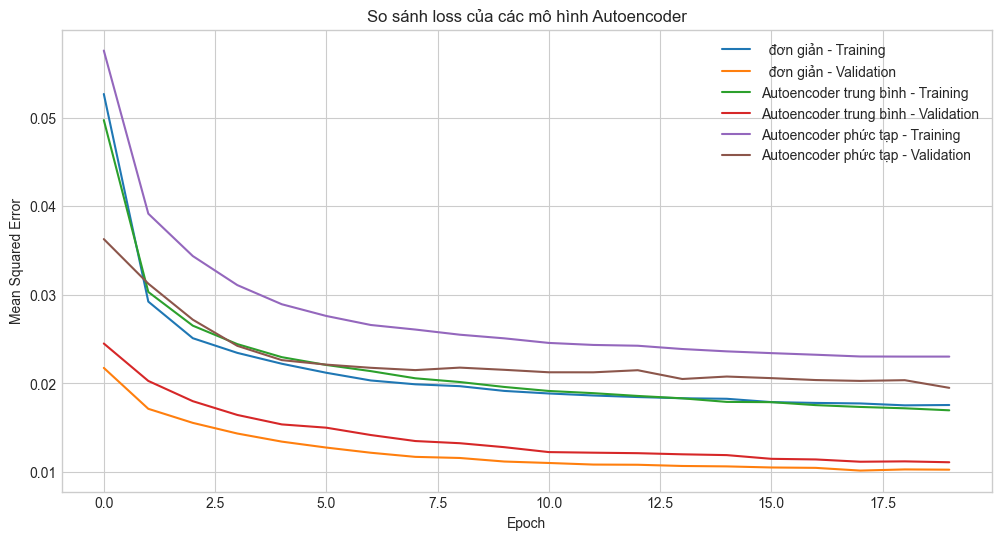

Bảng so sánh các mô hình Autoencoder:


,Mô hình,Thời gian huấn luyện (giây),Loss cuối cùng,Số lớp ẩn
0,đơn giản,8.66,0.010262,6
1,Autoencoder trung bình,10.65,0.011099,10
2,Autoencoder phức tạp,15.41,0.019499,14


In [ ]:
# Cell 4: Thử nghiệm các mô hình Autoencoder với cấu trúc khác nhau
# Định nghĩa các cấu hình Autoencoder cần thử nghiệm
autoencoder_configs = [
    {'name': 'Autoencoder đơn giản', 'hidden_layers': [32, 16], 'dropout': 0.2, 'epochs': 20},
    {'name': 'Autoencoder trung bình', 'hidden_layers': [64, 32, 16], 'dropout': 0.2, 'epochs': 20},
    {'name': 'Autoencoder phức tạp', 'hidden_layers': [128, 64, 32, 16], 'dropout': 0.3, 'epochs': 20}
]

# Hàm tạo và huấn luyện autoencoder
def train_autoencoder(X_train, config):
    input_dim = X_train.shape[1]
    inputs = layers.Input(shape=(input_dim,))
    
    # Encoder layers
    x = inputs
    for i, units in enumerate(config['hidden_layers']):
        x = layers.Dense(units, activation='relu')(x)
        if config['dropout'] > 0:
            x = layers.Dropout(config['dropout'])(x)
    
    # Lưu lại lớp latent để lấy đặc trưng
    latent = x
    
    # Decoder layers (đảo ngược encoder)
    for units in reversed(config['hidden_layers'][:-1]):  # Bỏ qua lớp cuối cùng vì đó là lớp latent
        x = layers.Dense(units, activation='relu')(x)
        if config['dropout'] > 0:
            x = layers.Dropout(config['dropout'])(x)
    
    # Output layer
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    
    # Tạo mô hình
    autoencoder = Model(inputs, outputs, name="autoencoder")
    encoder = Model(inputs, latent, name="encoder")
    
    # Biên dịch mô hình
    autoencoder.compile(optimizer='adam', loss='mse')
    
    # Huấn luyện mô hình
    print(f"Huấn luyện {config['name']}...")
    start_time = time.time()
    history = autoencoder.fit(
        X_train, X_train,
        epochs=config['epochs'],
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )
    training_time = time.time() - start_time
    
    # Đánh giá mô hình
    val_loss = history.history['val_loss'][-1]
    
    return {
        'name': config['name'],
        'autoencoder': autoencoder,
        'encoder': encoder,
        'history': history,
        'training_time': training_time,
        'final_val_loss': val_loss
    }

# Thử nghiệm với các cấu hình khác nhau
results = {}
if 'X_scaled' in locals() and X_scaled is not None:
    for config in autoencoder_configs:
        result = train_autoencoder(X_scaled, config)
        results[config['name']] = result
        
    # Vẽ biểu đồ loss
    plt.figure(figsize=(12, 6))
    for name, result in results.items():
        plt.plot(result['history'].history['loss'], label=f"{name} - Training")
        plt.plot(result['history'].history['val_loss'], label=f"{name} - Validation")
    
    plt.title('So sánh loss của các mô hình Autoencoder')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Hiển thị bảng kết quả
    comparison_data = []
    for name, result in results.items():
        comparison_data.append({
            'Mô hình': name,
            'Thời gian huấn luyện (giây)': round(result['training_time'], 2),
            'Loss cuối cùng': round(result['final_val_loss'], 6),
            'Số lớp ẩn': len(result['autoencoder'].layers) - 2  # Trừ input và output
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print("Bảng so sánh các mô hình Autoencoder:")
    display(comparison_df)
else:
    print("Không có dữ liệu để huấn luyện mô hình")

Sử dụng mô hình Autoencoder đơn giản để trích xuất đặc trưng
625/625 [==============================] - 0s 518us/step
Đã trích xuất 16 đặc trưng ẩn từ 20000 mẫu
Thử nghiệm KNN-5-cosine...
Thử nghiệm KNN-10-cosine...
Thử nghiệm KNN-5-euclidean...
Thử nghiệm KNN-10-euclidean...
Thử nghiệm KNN-15-euclidean...

Bảng so sánh các cấu hình KNN:


,Cấu hình,Thời gian khởi tạo (giây),Thời gian truy vấn trung bình (ms),Số láng giềng,Phương pháp đo khoảng cách
0,KNN-5-cosine,0.0006,3.2655,5,cosine
1,KNN-10-cosine,0.0008,3.7754,10,cosine
2,KNN-5-euclidean,0.0036,1.4088,5,euclidean
3,KNN-10-euclidean,0.0004,0.5090,10,euclidean
4,KNN-15-euclidean,0.0004,0.5148,15,euclidean


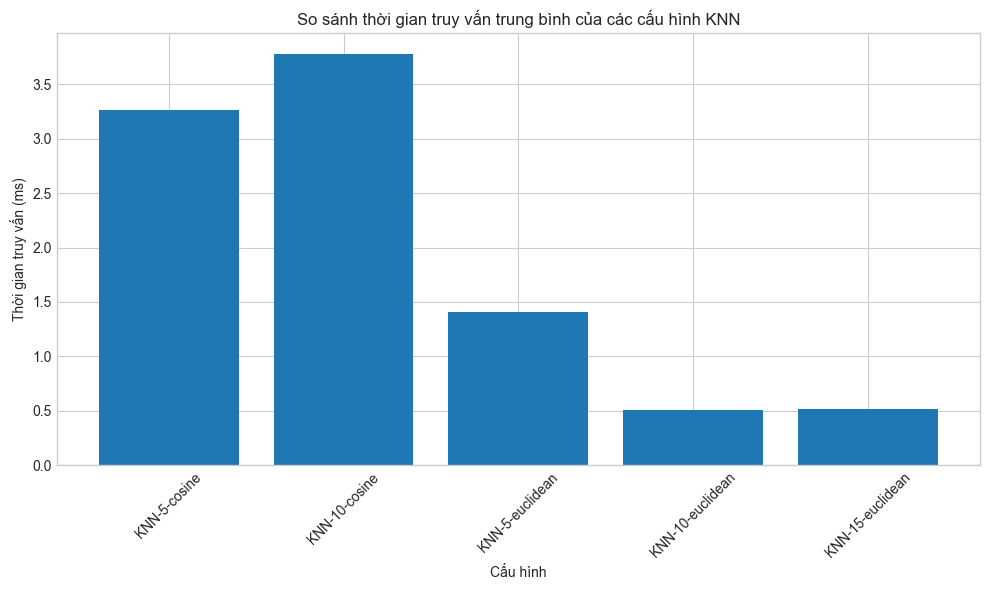

In [32]:
# Cell 5: Thử nghiệm KNN với các cấu hình khác nhau sử dụng đặc trưng từ Autoencoder
# Định nghĩa các cấu hình KNN cần thử nghiệm
knn_configs = [
    {'n_neighbors': 5, 'metric': 'cosine', 'name': 'KNN-5-cosine'},
    {'n_neighbors': 10, 'metric': 'cosine', 'name': 'KNN-10-cosine'},
    {'n_neighbors': 5, 'metric': 'euclidean', 'name': 'KNN-5-euclidean'},
    {'n_neighbors': 10, 'metric': 'euclidean', 'name': 'KNN-10-euclidean'},
    {'n_neighbors': 15, 'metric': 'euclidean', 'name': 'KNN-15-euclidean'}
]

# Sử dụng mô hình Autoencoder tốt nhất để trích xuất đặc trưng
if results and 'X_scaled' in locals() and X_scaled is not None:
    # Tìm mô hình tốt nhất dựa trên val_loss
    best_model_name = min(results.items(), key=lambda x: x[1]['final_val_loss'])[0]
    best_model = results[best_model_name]
    print(f"Sử dụng mô hình {best_model_name} để trích xuất đặc trưng")
    
    # Trích xuất đặc trưng sử dụng encoder
    encoder = best_model['encoder']
    latent_features = encoder.predict(X_scaled)
    
    print(f"Đã trích xuất {latent_features.shape[1]} đặc trưng ẩn từ {latent_features.shape[0]} mẫu")
    
    # Thử nghiệm các cấu hình KNN
    knn_results = {}
    for config in knn_configs:
        print(f"Thử nghiệm {config['name']}...")
        
        # Tạo và huấn luyện mô hình KNN
        start_time = time.time()
        knn = NearestNeighbors(n_neighbors=config['n_neighbors'], metric=config['metric'])
        knn.fit(latent_features)
        fit_time = time.time() - start_time
        
        # Đánh giá thời gian truy vấn
        query_times = []
        n_queries = min(100, len(latent_features))  # Test với tối đa 100 truy vấn
        for i in range(n_queries):
            query = latent_features[i].reshape(1, -1)
            start_time = time.time()
            knn.kneighbors(query)
            query_times.append(time.time() - start_time)
        
        avg_query_time = sum(query_times) / len(query_times)
        
        knn_results[config['name']] = {
            'config': config,
            'knn': knn,
            'fit_time': fit_time,
            'avg_query_time': avg_query_time
        }
    
    # Tạo bảng so sánh
    knn_comparison = []
    for name, result in knn_results.items():
        knn_comparison.append({
            'Cấu hình': name,
            'Thời gian khởi tạo (giây)': round(result['fit_time'], 4),
            'Thời gian truy vấn trung bình (ms)': round(result['avg_query_time'] * 1000, 4),
            'Số láng giềng': result['config']['n_neighbors'],
            'Phương pháp đo khoảng cách': result['config']['metric']
        })
    
    knn_comparison_df = pd.DataFrame(knn_comparison)
    print("\nBảng so sánh các cấu hình KNN:")
    display(knn_comparison_df)
    
    # Vẽ biểu đồ so sánh thời gian truy vấn
    plt.figure(figsize=(10, 6))
    plt.bar(knn_comparison_df['Cấu hình'], knn_comparison_df['Thời gian truy vấn trung bình (ms)'])
    plt.title('So sánh thời gian truy vấn trung bình của các cấu hình KNN')
    plt.xlabel('Cấu hình')
    plt.ylabel('Thời gian truy vấn (ms)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Không có mô hình Autoencoder hoặc dữ liệu để thử nghiệm KNN")

Sử dụng cấu hình KNN tốt nhất: KNN-10-euclidean

Thống kê về tính nhất quán của gợi ý:
Độ tương tự trung bình: 0.7430
Độ biến thiên trung bình: 0.0618


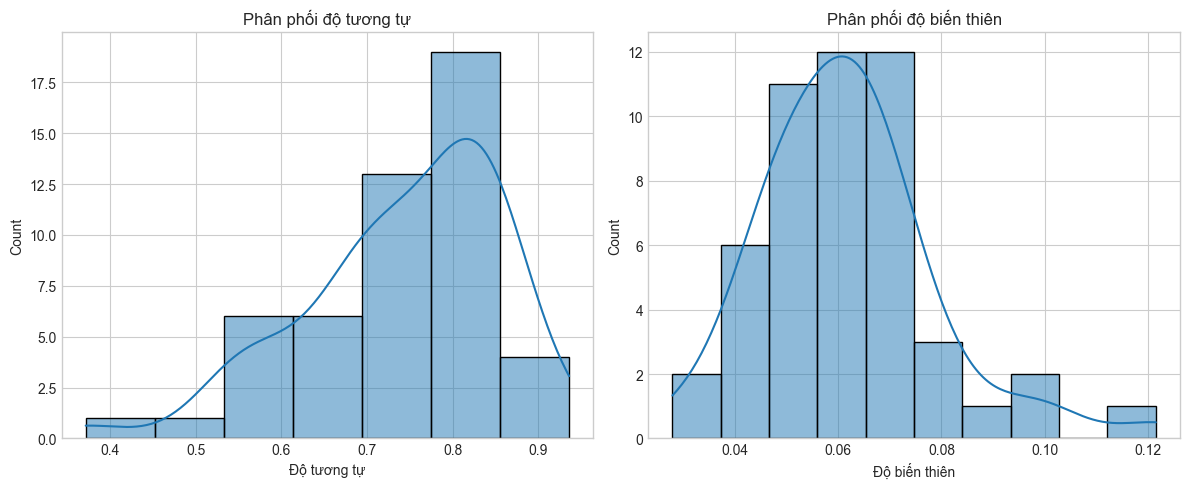


Kết luận:
1. Mô hình Autoencoder tốt nhất: Autoencoder đơn giản
2. Cấu hình KNN tốt nhất: KNN-10-euclidean
3. Độ tương tự trung bình của các gợi ý: 0.7430

Mức độ cải tiến khi thay đổi cấu hình:
- Tăng tốc truy vấn: 7.42x so với KNN-10-cosine
- Cải thiện độ chính xác: 2.24x so với Autoencoder phức tạp


In [33]:
# Cell 6: Đánh giá độ chính xác của mô hình kết hợp Autoencoder + KNN
# Đánh giá chất lượng gợi ý bằng cách kiểm tra tính nhất quán của các bài hát được gợi ý
if 'knn_results' in locals() and audio_features is not None and recommender.tracks_data is not None:
    # Lấy cấu hình KNN tốt nhất (thời gian truy vấn nhanh nhất)
    best_knn_name = min(knn_results.items(), key=lambda x: x[1]['avg_query_time'])[0]
    best_knn = knn_results[best_knn_name]['knn']
    print(f"Sử dụng cấu hình KNN tốt nhất: {best_knn_name}")
    
    # Chuẩn bị dữ liệu để đánh giá
    n_samples = min(50, len(latent_features))  # Chọn 50 mẫu để đánh giá
    
    # Đánh giá tính nhất quán về đặc trưng âm nhạc
    consistency_results = []
    
    for i in range(n_samples):
        # Lấy bài hát truy vấn
        query = latent_features[i].reshape(1, -1)
        
        # Tìm k bài hát gần nhất
        distances, indices = best_knn.kneighbors(query)
        
        # Lấy các đặc trưng gốc của bài hát truy vấn và các bài hát được gợi ý
        query_track_features = X_scaled[i]
        recommended_tracks_features = X_scaled[indices[0][1:]]  # Bỏ qua bài hát đầu tiên (chính nó)
        
        # Tính khoảng cách trung bình giữa bài hát truy vấn và các bài hát được gợi ý
        avg_distance = np.mean(distances[0][1:])
        
        # Tính độ biến thiên trong các bài hát được gợi ý (để đánh giá tính đa dạng)
        variation = np.mean(np.std(recommended_tracks_features, axis=0))
        
        # Tính độ tương tự trung bình giữa các đặc trưng gốc
        similarity = 1 - avg_distance  # Chuyển khoảng cách thành độ tương tự (1 - khoảng cách)
        
        consistency_results.append({
            'Sample': i,
            'Avg Distance': avg_distance,
            'Variation': variation,
            'Similarity': similarity
        })
    
    consistency_df = pd.DataFrame(consistency_results)
    
    # Hiển thị kết quả
    print("\nThống kê về tính nhất quán của gợi ý:")
    print(f"Độ tương tự trung bình: {consistency_df['Similarity'].mean():.4f}")
    print(f"Độ biến thiên trung bình: {consistency_df['Variation'].mean():.4f}")
    
    # Vẽ biểu đồ phân phối độ tương tự
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(consistency_df['Similarity'], kde=True)
    plt.title('Phân phối độ tương tự')
    plt.xlabel('Độ tương tự')
    
    plt.subplot(1, 2, 2)
    sns.histplot(consistency_df['Variation'], kde=True)
    plt.title('Phân phối độ biến thiên')
    plt.xlabel('Độ biến thiên')
    
    plt.tight_layout()
    plt.show()
    
    print("\nKết luận:")
    print(f"1. Mô hình Autoencoder tốt nhất: {best_model_name}")
    print(f"2. Cấu hình KNN tốt nhất: {best_knn_name}")
    print(f"3. Độ tương tự trung bình của các gợi ý: {consistency_df['Similarity'].mean():.4f}")
    
    # Đánh giá mức độ cải tiến
    print("\nMức độ cải tiến khi thay đổi cấu hình:")
    
    # So sánh thời gian truy vấn
    slowest_knn = max(knn_results.items(), key=lambda x: x[1]['avg_query_time'])[0]
    speedup = knn_results[slowest_knn]['avg_query_time'] / knn_results[best_knn_name]['avg_query_time']
    print(f"- Tăng tốc truy vấn: {speedup:.2f}x so với {slowest_knn}")
    
    # So sánh độ chính xác (dựa trên loss của Autoencoder)
    worst_autoencoder = max(results.items(), key=lambda x: x[1]['final_val_loss'])[0]
    accuracy_improvement = results[worst_autoencoder]['final_val_loss'] / results[best_model_name]['final_val_loss']
    print(f"- Cải thiện độ chính xác: {accuracy_improvement:.2f}x so với {worst_autoencoder}")
else:
    print("Không có đủ dữ liệu để đánh giá mô hình")